# Fighting Game Esports Analysis

Emmanuel M. Fe Benito \
2023029891 \
APM1220

### Description of the Simulation

The simulation will analyze the metrics often used to compare and evaluate the skill and efficiency of fighting game players in an esports scenario. The three variables chosen were Reaction Time(ms) ($X_{1}$), Inputs per Minutes(ipm) ($X_{2}$), and Combo Accuracy(percent) ($X_{3}$). The simulation assumes that each variable should be related to each other, such as a decrease in reaction time leads to an increase in inputs per minutes and that an increase in Inputs per Minutes leads to an increase in Combo Accuracy.

### Definition of  $\mu$ and $\Sigma$

We specify our multivariate normal distribution $X \sim N_{p}(\mu, \Sigma)$ with a valid, positive-definite covariance matrix:

$$\mu = \begin{bmatrix} 200 \\ 300 \\ 85 \end{bmatrix}$$

$$\Sigma = \begin{bmatrix} 400 & -360 & -50 \\ -360 & 900 & 60 \\ -50 & 60 & 25 \end{bmatrix}$$

### 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, norm

# Seed
np.random.seed(123)

## Part A: Define Your Multivariate Normal Distribution

In [3]:
# Define Parameters

mu = np.array([200, 300, 85])
Sigma = np.array([
    [400, -360, -50],
    [-360, 900, 60],
    [-50, 60, 25]
])

# Generating 3000 observations
n = 3000
data = np.random.multivariate_normal(mu, Sigma, n)
df = pd.DataFrame(data, columns=['Reaction_Time', 'IPM', 'Combo_Accuracy'])

The covaraince matrix is appropriate as it is mathematically sound and realistic.

The diagonal numbers represent how much players vary in skill as taking their squareroot is the typical deviation between each players. Reaction Time has a standard deviation of 20 ms, IPM has a standard deviation of 30 ipm, and Combo Accuracy has a standard deviation of 5%. With the off-diagonals representing their relationship, Reaction Time has a strong negative relationship with IPM and a weaker negative relationship with Combo Accuracy while IPM and Combo Accuracy have a moderate positive relationship.

## Part B. Generate and Explore the Simulated Data

In [14]:
# Calculate Theoretical Variances and Correlation Matrix
theo_variances = np.diag(Sigma)
std_devs = np.sqrt(theo_variances)
theo_corr = Sigma / np.outer(std_devs, std_devs)

# Descriptive Statistics

print("Means")
print(f"Theoretical: {mu}")
print(f"Simulated:   {df.mean().round(2).values}\n")

print("Variances")
print(f"Theoretical: {theo_variances}")
print(f"Simulated:   {df.var().round(2).values}\n")

print("Covariances")
print("Theoretical:\n", Sigma)
print("Simulated:\n", df.cov().round(2).values, "\n")

print("Correlations")
print("Theoretical:\n", theo_corr.round(2))
print("Simulated:\n", df.corr().round(2).values)

Means
Theoretical: [200 300  85]
Simulated:   [199.38 300.54  85.06]

Variances
Theoretical: [400 900  25]
Simulated:   [395.86 858.85  25.43]

Covariances
Theoretical:
 [[ 400 -360  -50]
 [-360  900   60]
 [ -50   60   25]]
Simulated:
 [[ 395.86 -342.71  -50.86]
 [-342.71  858.85   56.16]
 [ -50.86   56.16   25.43]] 

Correlations
Theoretical:
 [[ 1.  -0.6 -0.5]
 [-0.6  1.   0.4]
 [-0.5  0.4  1. ]]
Simulated:
 [[ 1.   -0.59 -0.51]
 [-0.59  1.    0.38]
 [-0.51  0.38  1.  ]]


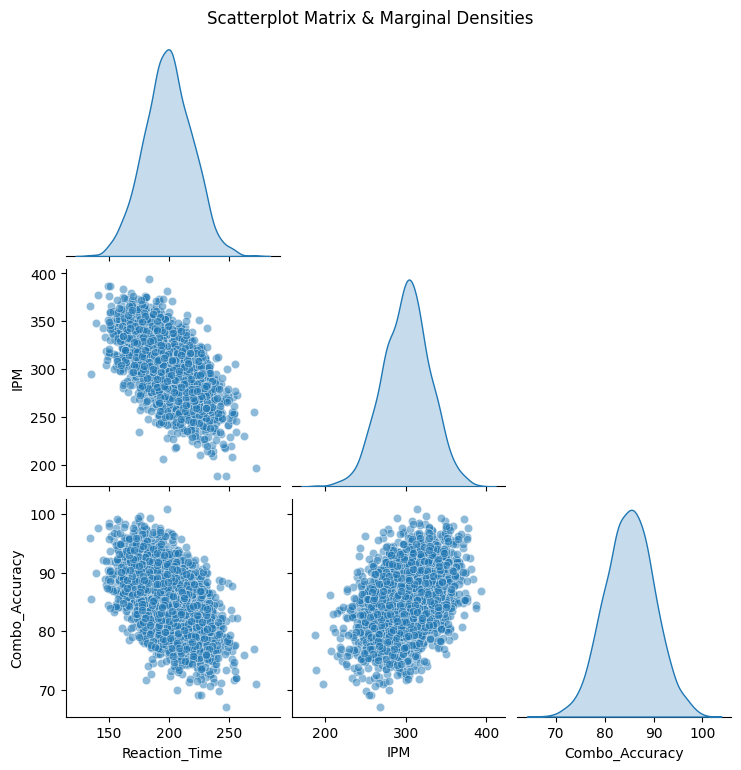

In [17]:
# Visualization

# Plot 1: Scatterplot Matrix / Pairs Plot
sns.pairplot(df, corner=True, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Scatterplot Matrix & Marginal Densities", y=1.02)
plt.show()

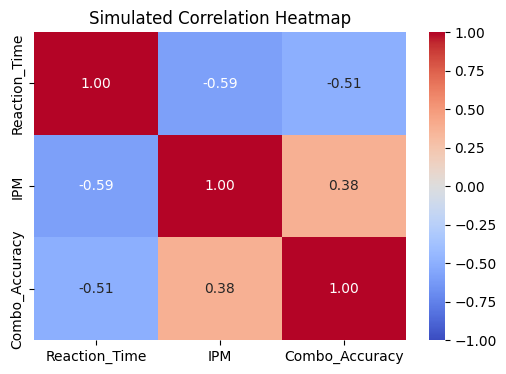

In [18]:
# Plot 2: Correlation Visualization (Heatmap)
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Simulated Correlation Heatmap")
plt.show()

### Intepretation

- After simulation, all 4 of the descriptive statistics: means, variance, covariances, and correlations, closely match that of their theoretical counterpart. Each one confirms that our simulation population of 3000 is sufficient enough to properly simulate our $\mu$ and $\Sigma$ while minimizing any random sampling errors. The only slight hiccup is the simulated variance on Inputs per Minute (Theoretical - 900 vs Simulated -  858.85), though the difference is marginal considering the high numbers present.

- The graphical displays reflect our initial assumptions as well, showing that less Reaction Time generally reflect higher IPM and Combo Accuracy due to its downward slope, whilst higher IPM led to a higher Combo Accuracy, due to its upward slope. With the Correlation Matrix showing a postive correlation to IPM and Combo Accuracy, which is due to their positive relation to each other, while Reaction Time due to its nature as a variable that ideally wants to go down as much as possible has therefore a negative correlation to the other two variables, with Reaction Time also having the strongest correlation among all the variable together.

## Part C. Investigate the Effect of Correlation

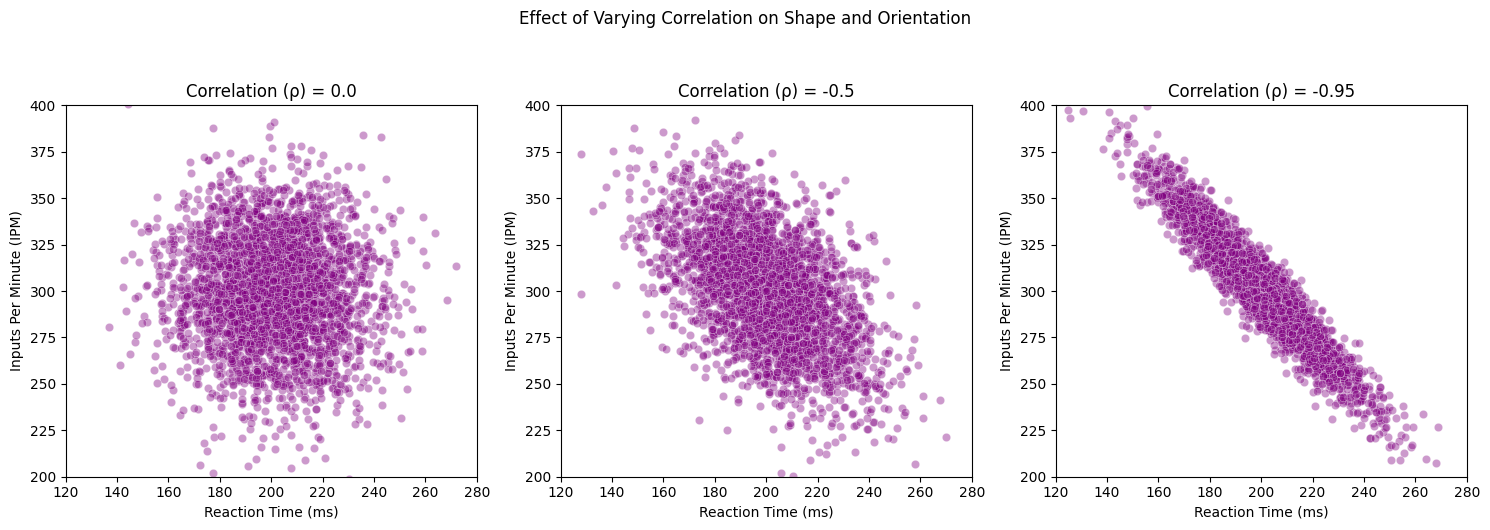

In [19]:
# We will test three different correlations (rho) between X1 and X2.
# Standard deviations for X1 and X2 are 20 and 30, respectively (20 * 30 = 600)
rhos_to_test = [0.0, -0.50, -0.95]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, rho in enumerate(rhos_to_test):
    Sigma_test = np.copy(Sigma)

    # Calculate and inject the new covariance (Cov = rho * std1 * std2)
    new_cov = rho * 600
    Sigma_test[0, 1] = Sigma_test[1, 0] = new_cov

    # Generate new observations with the modified correlation structure
    data_test = np.random.multivariate_normal(mu, Sigma_test, n)

    # Visualization
    sns.scatterplot(x=data_test[:, 0], y=data_test[:, 1], ax=axes[i], alpha=0.4, color='purple')

    axes[i].set_title(f"Correlation (ρ) = {rho}")
    axes[i].set_xlabel("Reaction Time (ms)")
    axes[i].set_ylabel("Inputs Per Minute (IPM)")
    axes[i].set_xlim(120, 280)
    axes[i].set_ylim(200, 400)

plt.suptitle("Effect of Varying Correlation on Shape and Orientation", y=1.05)
plt.tight_layout()
plt.show()

### Discussion

Taking a look at the graphs, a correlation of 0 shows a circular cloud that tells that the relationship between the two variables is that they are linearly independent with each other. While looking at two other correlation we get a more proper look at the relationship. In fact just seeing the -0.5 correlation already shows that a clear conclusion can be drawn on their relationship and that a stronger correlation only seeks to confirm this conclusion.

As the correlation grows stronger the shape also becomes more defined from a ball to an ellipse to, when taken into the extreme, a clear straight line. Showing the concept of concentration of probability along a line. This means that when two variables are under such a strong correlation predicting the other's values with only one of each becomes not only easy but also becomes increasingly accurate.

## Part D. Investigate a Linear Combination

Linear Combination Comparison
Theoretical Mean: 270 | Simulated Mean: 271.27
Theoretical Variance: 2560 | Simulated Variance: 2469.94


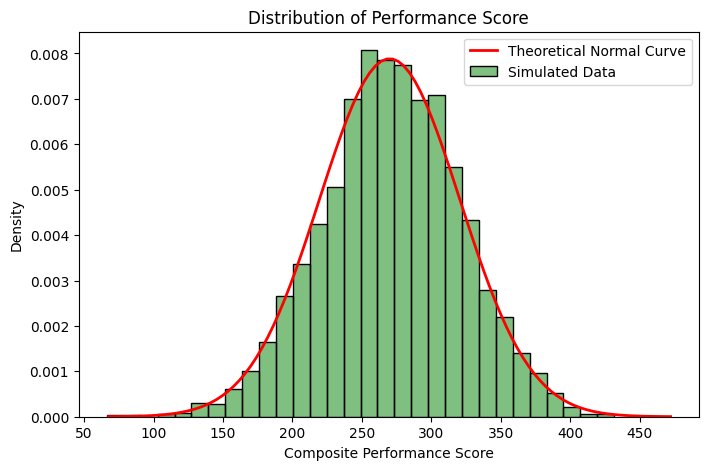

In [23]:
# 1. Define the linear combination weights (vector a)
# Performance Score Y = -1(Reaction_Time) + 1(IPM) + 2(Combo_Accuracy)
a = np.array([-1, 1, 2])

# 2 & 3. Calculate the theoretical mean and theoretical variance
theo_mean_Y = a.T @ mu
theo_var_Y = a.T @ Sigma @ a

# 4. Calculate the corresponding simulated mean and variance
df['Performance_Score'] = -1 * df['Reaction_Time'] + 1 * df['IPM'] + 2 * df['Combo_Accuracy']
sim_mean_Y = df['Performance_Score'].mean()
sim_var_Y = df['Performance_Score'].var()

# 5. Compare the theoretical and simulated results
print("Linear Combination Comparison")
print(f"Theoretical Mean: {theo_mean_Y} | Simulated Mean: {sim_mean_Y:.2f}")
print(f"Theoretical Variance: {theo_var_Y} | Simulated Variance: {sim_var_Y:.2f}")

# 6. Produce an appropriate graph of the simulated linear combination
plt.figure(figsize=(8, 5))
sns.histplot(df['Performance_Score'], stat='density', bins=30, alpha=0.5, color='green', label='Simulated Data')

# Overlay of theorical over simulated
std_dev_Y = np.sqrt(theo_var_Y)
x_vals_Y = np.linspace(theo_mean_Y - 4*std_dev_Y, theo_mean_Y + 4*std_dev_Y, 100)
plt.plot(x_vals_Y, norm.pdf(x_vals_Y, theo_mean_Y, std_dev_Y), 'r-', lw=2, label='Theoretical Normal Curve')

plt.title("Distribution of Performance Score")
plt.xlabel("Composite Performance Score")
plt.ylabel("Density")
plt.legend()
plt.show()

### Discussion

The linear combination of the Performance Score first uses the weight vector of $a = [-1, 1, 2]^T$ and the formula $Y = -1X_1 + 1X_2 + 2X_3$. This weight vector was chosen in order to penalize high Reaction Times and reward high IPM and especialy Combo Accuracy.

Both the mean and variance, alongside the graph supports the theoretical result. The mean is the closest with only a difference of 1.27, while the variance has the highest difference of 90.06, though this difference may seem like a lot given the high values present the difference becomes negligible. This is further compounded when looking at the graph showing that the simulated performance score follows the pattern of the theoretical very closely. Showing that a linear combination of multivariate normal variables will follow the theoretical result, the univariate normal distribution aka $a^{\prime}X \sim N(a^{\prime}\mu, a^{\prime}\Sigma a)$.

## Part E. Mahalanobis Distance and Chi-Square

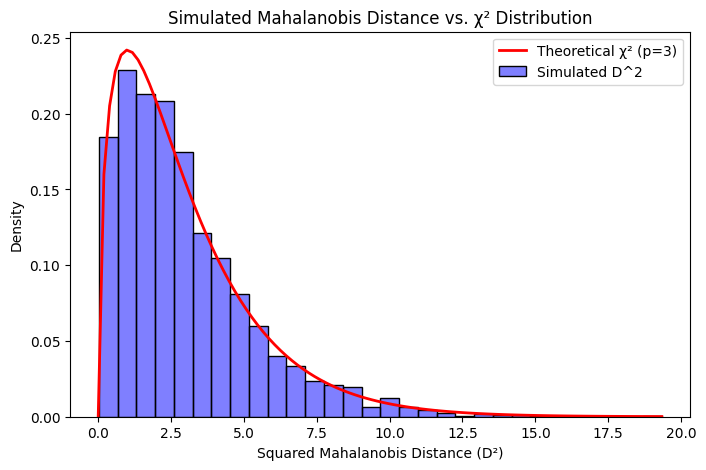

Results
90% Critical Value (Theoretical): 6.25
Proportion inside 90% region (Simulated): 90.43%


In [29]:
# 1. Calculation of D^2 for the simulated observations

# Calculate the inverse of the covariance matrix
Sigma_inv = np.linalg.inv(Sigma)

# Calculate (x - mu) for all observations
diff = df[['Reaction_Time', 'IPM', 'Combo_Accuracy']].values - mu

# Calculate D^2 = (x - mu)' Sigma^-1 (x - mu) for each row
D2 = np.einsum('ij,jk,ik->i', diff, Sigma_inv, diff)
df['Mahalanobis_D2'] = D2

# 2 & 3. Histogram of D^2 and comparison with theoretical Chi-Square
plt.figure(figsize=(8, 5))
sns.histplot(df['Mahalanobis_D2'], stat='density', bins=30, alpha=0.5, color='blue', label='Simulated D^2')

# Overlay of theoretical Chi-Square distribution
p = 3
x_vals_chi2 = np.linspace(0, df['Mahalanobis_D2'].max(), 100)
plt.plot(x_vals_chi2, chi2.pdf(x_vals_chi2, df=p), 'r-', lw=2, label='Theoretical χ² (p=3)')

plt.title("Simulated Mahalanobis Distance vs. χ² Distribution")
plt.xlabel("Squared Mahalanobis Distance (D²)")
plt.ylabel("Density")
plt.legend()
plt.show()

# 4. Proportion of observations inside the 90% theoretical region

# Find the critical value for the 90th percentile of Chi-Square with df=3
critical_value_90 = chi2.ppf(0.90, df=p)

# Calculate the proportion of simulated values below this critical value
proportion_inside = np.mean(df['Mahalanobis_D2'] <= critical_value_90)

print("Results")
print(f"90% Critical Value (Theoretical): {critical_value_90:.2f}")
print(f"Proportion inside 90% region (Simulated): {proportion_inside * 100:.2f}%")

### Discussion

The Mahalanobis distance measures how far a data point is from the mean of the group. Looking at the graph provided both the theoretical and the simualted show a right skewed histogram, showing then that our current group of values don't deviate much from the mean and that the squared Mahalanobis distance does in fact follow the chi-square distribution ($D^2 \sim \chi^2_p$, with p = 3).
The proportion of observations falling inside the 90% region also further confirms this as this means that around 90.43% of all players stay within the expected region around the mean, showing that only a small 10% of players are designated as outliers.

## Custom Investigation

### Option C - Conditional Distribution

In [30]:
# We will condition Reaction Time (X1) on Inputs Per Minute (X2) = 330
x2_cond = 330

# Extract the specific variance and covariance parameters from our theoretical matrix
sigma11 = Sigma[0, 0]  # Variance of Reaction Time (400)
sigma22 = Sigma[1, 1]  # Variance of IPM (900)
sigma12 = Sigma[0, 1]  # Covariance between them (-360)

# Theoretical calculations
# E(X1 | X2 = x2) = mu1 + (sigma12 / sigma22) * (x2 - mu2)
cond_mean_X1 = mu[0] + (sigma12 / sigma22) * (x2_cond - mu[1])

# Var(X1 | X2) = sigma11 - (sigma12^2 / sigma22)
cond_var_X1 = sigma11 - ((sigma12**2) / sigma22)

print("Theoretical Conditional Distribution")
print(f"Expected Mean E(X1 | X2 = 330): {cond_mean_X1}")
print(f"Expected Variance Var(X1 | X2): {cond_var_X1}")

# Simulated calculations
tolerance = 5
sim_cond_data = df[(df['IPM'] >= x2_cond - tolerance) & (df['IPM'] <= x2_cond + tolerance)]

sim_cond_mean = sim_cond_data['Reaction_Time'].mean()
sim_cond_var = sim_cond_data['Reaction_Time'].var()

print("\nSimulated Conditional Distribution")
print(f"Simulated Conditional Mean: {sim_cond_mean:.2f}")
print(f"Simulated Conditional Variance: {sim_cond_var:.2f}")
print(f"Number of observations in conditional subset: {len(sim_cond_data)}")

Theoretical Conditional Distribution
Expected Mean E(X1 | X2 = 330): 188.0
Expected Variance Var(X1 | X2): 256.0

Simulated Conditional Distribution
Simulated Conditional Mean: 187.02
Simulated Conditional Variance: 217.09
Number of observations in conditional subset: 223


### Discussion

The simulation was to compare the results of a simulated and theoretical conditional distribution. The conditional distribution was to the Reaction Time based on a Inputs per Minute of 330.

Comparing both the simulated and theoretical they once again closely follow each other fairly well, with the largest difference being in the variance (a difference of 39). Though this difference is to be expected as we had used a tolerance of 5 to filter and get the values of IPM near 330, so the larger variance is to be expected. These results following the theoretical results means that the property of the multivariate normal distribution that states that any subset conditioned on another variable remains normally distributed, is factually correct and proven here.

## Conclusion

After multiple tests and simulations our initial parameters chosen for this Esports Analysis are mathematically sound and properly follow all the properties present in a multivariate normal distribution. Each part of the simulation lab only continued to further confirm these properties showing that our multivariate normal distribution is a proper multivariate normal distribution.